# <font color="#418FDE" size="6.5" uppercase>**Model Cards and Governance**</font>

>Last update: 20260424.
    
By the end of this Lecture, you will be able to:
- Create a concise model card that documents a civil engineering AI model’s purpose, data, performance, and limitations. 
- Draft a simple risk register that records key risks, controls, and monitoring plans for an AI deployment. 
- Evaluate whether a proposed AI use case has sufficient documentation and governance to proceed responsibly. 


## **1. Model Card Basics**

### **1.1. Intended Users**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_01_01.jpg?v=1777047205" width="250">



>* Specify trained users and professional context.
>* Clarify supported decisions, not final judgments.

>* Explain user context and model support.
>* Prevent overreach beyond technical decision support.

>* Name appropriate and inappropriate users clearly.
>* Keep high-stakes decisions under human oversight.



In [1]:
#@title Python Code - Intended Users

# This script shows model card basics.
# We focus on intended users clearly.
# Civil engineering examples stay simple.

# Import small teaching libraries.
import numpy as np
import pandas as pd

# Set deterministic seeds safely.
np.random.seed(7)

# Create a tiny civil dataset.
ages = np.array([1, 3, 7, 14, 28, 56])
strength = np.array([12, 18, 26, 33, 41, 47])

# Build a simple table.
data = pd.DataFrame({
    "Age_days": ages,

    "Strength_MPa": strength})

# Define a simple threshold rule.
mean_strength = float(data["Strength_MPa"].mean())
label = data["Strength_MPa"] >= mean_strength

# Add labels for documentation.
data["Class"] = np.where(label, "Higher", "Lower")

# Create a concise model card.
model_card = pd.DataFrame({
    "Field": [

        "Model name",
        "Intended use",
        "Intended users",

        "Out-of-scope users",
        "Human oversight",
        "Safety note"],

    "Details": [
        "Concrete strength screening helper",
        "Early screening of likely higher strength mixes",

        "Materials engineers and trained lab analysts",
        "Public users, procurement staff, untrained operators",
        "Engineers must review lab results before decisions",

        "Not for final design approval or safety sign-off"]})

# Check the table size.
if len(model_card) != 6:
    raise ValueError("Model card size is unexpected.")

# Show a short data preview.
print("Tiny dataset preview:")
print(data.head(3).to_string(index=False))

# Show the intended users section.
print("\nModel card fields:")
print(model_card.to_string(index=False))

Tiny dataset preview:
 Age_days  Strength_MPa Class
        1            12 Lower
        3            18 Lower
        7            26 Lower

Model card fields:
             Field                                              Details
        Model name                   Concrete strength screening helper
      Intended use      Early screening of likely higher strength mixes
    Intended users         Materials engineers and trained lab analysts
Out-of-scope users Public users, procurement staff, untrained operators
   Human oversight   Engineers must review lab results before decisions
       Safety note     Not for final design approval or safety sign-off


### **1.2. Training Data Overview**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_01_02.jpg?v=1777047231" width="250">



>* Describe data source, scope, and labeling.
>* Clarify conditions covered for deployment relevance.

>* Show dataset gaps and representativeness clearly
>* Coverage matters more than dataset size

>* Describe cleaning, labeling, and data uncertainty.
>* Note outdated practices, bias, and caution.



TensorFlow version: 2.21.0
GPU available: False

Training Data Overview
            Item                         Value
  Dataset source Yeh concrete strength dataset
  Domain example           Concrete mix design
            Rows                          1030
  Input features                             8
          Target      Compressive strength MPa
     Train split                           721
Validation split                           154
      Test split                           155
   Preprocessing    Standardize numeric inputs
          Epochs                            20

Test MAE: 12.43 MPa
Test R2: 0.1


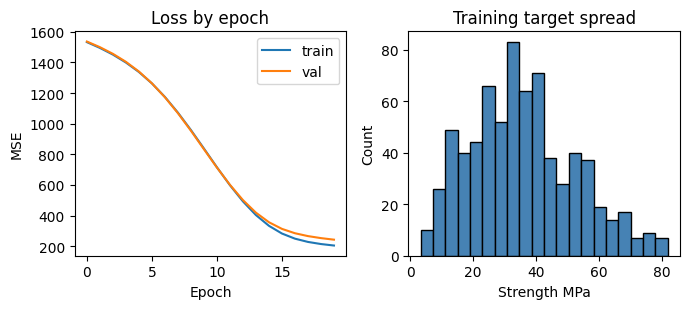

In [2]:
#@title Python Code - Training Data Overview

# This script shows training data basics.
# It builds a compact model card.
# It uses a small TensorFlow example.

# Silence TensorFlow warning messages.
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")

# Import beginner friendly libraries.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Import TensorFlow and metrics.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import r2_score

tf.get_logger().setLevel("ERROR")
np.random.seed(7)
tf.random.set_seed(7)

# Show framework version briefly.
print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

# Download the civil engineering dataset.
!wget -q -O concrete_compressive_strength.csv "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"

# Load the dataset safely.
df = pd.read_csv("concrete_compressive_strength.csv")
df.columns = [

    "cement", "slag", "fly_ash", "water",
    "superplasticizer", "coarse_agg", "fine_agg", "age",
    "strength"]

# Check basic dataset shape.
if df.shape[0] < 100 or df.shape[1] != 9:
    raise ValueError("Dataset shape is unexpected.")

# Split features and target.
X = df.drop("strength", axis=1).copy()
y = df["strength"].copy()

# Create deterministic split masks.
indices = np.arange(len(df))
np.random.shuffle(indices)

train_end = int(0.7 * len(df))
val_end = int(0.85 * len(df))

# Build train validation test sets.
train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]

test_idx = indices[val_end:]

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()
y_test = y.iloc[test_idx].copy()

# Standardize using training statistics.
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1)

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Build a small regression model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1)])

# Compile the model quietly.
model.compile(
    optimizer="adam",

    loss="mse",
    metrics=["mae"])

# Train for a few epochs.
history = model.fit(
    X_train, y_train,

    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,

    verbose=0)

# Evaluate on the test set.
preds = model.predict(X_test, verbose=0).flatten()
test_mae = mean_absolute_error(y_test, preds)

test_r2 = r2_score(y_test, preds)

# Create compact metadata table.
metadata = pd.DataFrame({
    "Item": [

        "Dataset source", "Domain example", "Rows",
        "Input features", "Target", "Train split",
        "Validation split", "Test split", "Preprocessing",

        "Epochs"],
    "Value": [
        "Yeh concrete strength dataset", "Concrete mix design",

        str(len(df)), str(X.shape[1]), "Compressive strength MPa",
        str(len(train_idx)), str(len(val_idx)), str(len(test_idx)),
        "Standardize numeric inputs", "20"]})

# Print a compact model card section.
print("\nTraining Data Overview")
print(metadata.to_string(index=False))

print("\nTest MAE:", round(float(test_mae), 2), "MPa")
print("Test R2:", round(float(test_r2), 2))

# Plot training curves and target spread.
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
axes[0].plot(history.history["loss"], label="train")

axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss by epoch")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].hist(y_train, bins=20, color="steelblue", edgecolor="black")

axes[1].set_title("Training target spread")
axes[1].set_xlabel("Strength MPa")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### **1.3. Performance caveats**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_01_03.jpg?v=1777047270" width="250">



>* Performance depends on context, not headline accuracy.
>* State where results weaken and need caution.

>* Error types have different practical consequences.
>* State trade-offs and limits in real use.

>* Performance changes across places and time.
>* Document validation gaps and monitor ongoing drift.



TensorFlow version: 2.21.0

Model card: Performance summary
    metric   value
  accuracy   0.775
 precision   0.769
test_cases 120.000

Cohort results
   cohort  n_test  accuracy
day_clear      59     0.729
    night      37     0.811
  low_res      24     0.833

Known weaknesses
- Lower reliability for night or low-resolution images.
- Camera angle effects are not fully represented.
- Use manual review for safety-critical decisions.


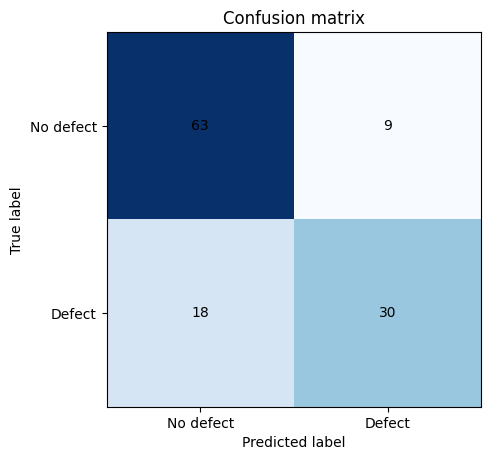

In [3]:
#@title Python Code - Performance caveats

# This script shows model card caveats.
# It uses a tiny TensorFlow example.
# Civil engineering context stays simple.

# Import quiet libraries and set seeds.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

# Import plotting and helper metrics.
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Print one short framework line.
print('TensorFlow version:', tf.__version__)

# Create simple synthetic inspection data.
n_samples = 600
lighting = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])

angle = np.random.choice([0, 1], n_samples, p=[0.75, 0.25])
resolution = np.random.choice([0, 1], n_samples, p=[0.8, 0.2])

# Build numeric features for defects.
crack_score = np.random.normal(0.0, 1.0, n_samples)
texture_score = np.random.normal(0.0, 1.0, n_samples)

moisture_score = np.random.normal(0.0, 1.0, n_samples)
noise = np.random.normal(0.0, 0.8, n_samples)

# Define labels with harder night cases.
base_signal = 1.2 * crack_score + 0.8 * texture_score
base_signal = base_signal - 0.7 * moisture_score + noise

base_signal = base_signal - 0.9 * lighting - 0.6 * angle
base_signal = base_signal - 0.5 * resolution
labels = (base_signal > 0.2).astype(int)

# Assemble a small dataframe.
df = pd.DataFrame()
df['crack_score'] = crack_score

df['texture_score'] = texture_score
df['moisture_score'] = moisture_score
df['night_image'] = lighting

df['odd_angle'] = angle
df['low_resolution'] = resolution
df['defect_present'] = labels

# Add readable cohort names.
df['cohort'] = 'day_clear'
df.loc[df['night_image'] == 1, 'cohort'] = 'night'

df.loc[df['low_resolution'] == 1, 'cohort'] = 'low_res'

# Split data into train and test.
train_df = df.sample(frac=0.8, random_state=7)
test_df = df.drop(train_df.index).copy()

feature_cols = ['crack_score', 'texture_score', 'moisture_score']

# Prepare arrays for TensorFlow.
X_train = train_df[feature_cols].to_numpy(dtype='float32')
y_train = train_df['defect_present'].to_numpy(dtype='float32')

X_test = test_df[feature_cols].to_numpy(dtype='float32')
y_test = test_df['defect_present'].to_numpy(dtype='int32')

# Check safe shapes before training.
if X_train.shape[0] < 50 or X_test.shape[0] < 20:
    raise ValueError('Dataset split is unexpectedly small.')

if X_train.shape[1] != 3:
    raise ValueError('Feature count should be three.')

# Build a lightweight neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),

    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')])

# Compile and train silently.
model.compile(
    optimizer='adam',

    loss='binary_crossentropy',
    metrics=['accuracy'])
model.fit(X_train, y_train, epochs=12, batch_size=32, verbose=0)

# Predict probabilities and classes.
probs = model.predict(X_test, verbose=0).reshape(-1)
preds = (probs >= 0.5).astype(int)

# Compute overall performance metrics.
overall_acc = accuracy_score(y_test, preds)
overall_prec = precision_score(y_test, preds, zero_division=0)

cm = confusion_matrix(y_test, preds)

# Build compact cohort metrics.
rows = []
for name in ['day_clear', 'night', 'low_res']:

    mask = test_df['cohort'].to_numpy() == name
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], preds[mask])

        rows.append([name, int(mask.sum()), round(acc, 3)])
cohort_table = pd.DataFrame(rows, columns=['cohort', 'n_test', 'accuracy'])

# Create a compact performance table.
perf_table = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'test_cases'],

    'value': [round(overall_acc, 3), round(overall_prec, 3), int(len(y_test))]})

# Print a concise model card section.
print('\nModel card: Performance summary')
print(perf_table.to_string(index=False))

print('\nCohort results')
print(cohort_table.to_string(index=False))

# Print caveats in plain language.
print('\nKnown weaknesses')
print('- Lower reliability for night or low-resolution images.')

print('- Camera angle effects are not fully represented.')
print('- Use manual review for safety-critical decisions.')

# Plot one small confusion matrix.
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, cmap='Blues')

ax.set_title('Confusion matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

# Add matrix numbers and labels.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        ax.text(j, i, str(cm[i, j]), ha='center', va='center')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['No defect', 'Defect'])
ax.set_yticklabels(['No defect', 'Defect'])

plt.tight_layout()
plt.show()

## **2. Risk Register Basics**

### **2.1. Risks and Impacts**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_02_01.jpg?v=1777047317" width="250">



>* Name AI risks and practical impacts.
>* Include misuse, bias, drift, and consequences.

>* Impacts vary by context and affected groups.
>* Registers should capture harm severity and scale.

>* Risks arise across data, use, decisions.
>* Impacts depend on context and deployment.



Use case: Automated bridge defect screening
                           risk_description                                         impact  likelihood  severity              owner  priority
           Missed cracks in shadowed images      Delayed repairs may raise safety concerns           4         5    Inspection lead        20
Staff overtrust model scores without review Poor decisions may bypass engineering judgment           4         5     Asset engineer        20
  Biased data from easier to access bridges       Some bridges may receive unfair priority           3         4       Data manager        12
     Performance drops after camera changes    New images may reduce detection reliability           3         4          AI vendor        12
  False alarms increase inspection workload   Extra site visits can increase project costs           3         3 Operations manager         9


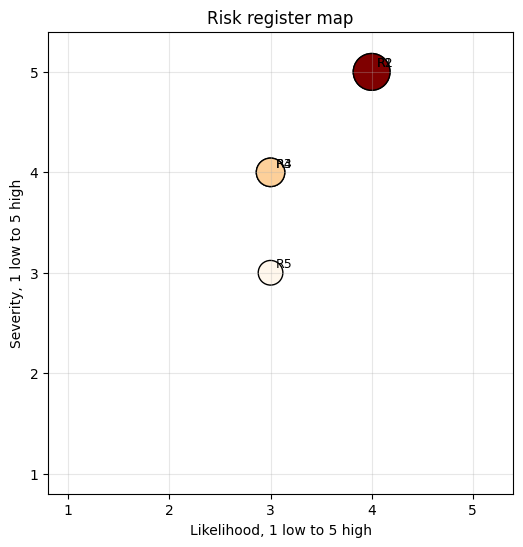

In [4]:
#@title Python Code - Risks and Impacts

# This script builds a simple risk register.
# It shows risks and impacts clearly.
# The example uses civil engineering governance.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seeds for repeatable results.
np.random.seed(7)

# Define one small AI use case.
use_case = "Automated bridge defect screening"

# Create beginner friendly risk entries.
risk_data = {
    "risk_description": [

        "Missed cracks in shadowed images",
        "False alarms increase inspection workload",
        "Biased data from easier to access bridges",

        "Staff overtrust model scores without review",
        "Performance drops after camera changes"],
    "impact": [

        "Delayed repairs may raise safety concerns",
        "Extra site visits can increase project costs",
        "Some bridges may receive unfair priority",

        "Poor decisions may bypass engineering judgment",
        "New images may reduce detection reliability"],
    "likelihood": [4, 3, 3, 4, 3],

    "severity": [5, 3, 4, 5, 4],
    "owner": [
        "Inspection lead",

        "Operations manager",
        "Data manager",
        "Asset engineer",

        "AI vendor"]}

# Build the risk register table.
risk_register = pd.DataFrame(risk_data)

# Add a simple priority score.
risk_register["priority"] = (
    risk_register["likelihood"] * risk_register["severity"])

# Sort highest priority risks first.
risk_register = risk_register.sort_values(
    by="priority", ascending=False)

# Reset row numbers for display.
risk_register = risk_register.reset_index(drop=True)

# Check the table size safely.
if risk_register.shape[0] == 0:
    raise ValueError("Risk register is empty.")

# Print a short title.
print("Use case:", use_case)

# Print a compact readable table.
print(
    risk_register.to_string(index=False))

# Create a compact scatter plot.
plt.figure(figsize=(6, 6))
plt.scatter(

    risk_register["likelihood"],
    risk_register["severity"],
    s=risk_register["priority"] * 35,

    c=risk_register["priority"],
    cmap="OrRd",
    edgecolors="black")

# Label each point briefly.
for i in range(len(risk_register)):
    short_name = "R" + str(i + 1)

    plt.text(
        risk_register.loc[i, "likelihood"] + 0.05,
        risk_register.loc[i, "severity"] + 0.05,

        short_name,
        fontsize=9)

# Add axis labels and limits.
plt.xlabel("Likelihood, 1 low to 5 high")
plt.ylabel("Severity, 1 low to 5 high")

plt.title("Risk register map")
plt.xlim(0.8, 5.4)
plt.ylim(0.8, 5.4)

# Add a light grid.
plt.grid(True, alpha=0.3)

# Show the final plot.
plt.show()

### **2.2. Controls and Monitoring**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_02_02.jpg?v=1777047348" width="250">



>* Controls reduce risk through practical safeguards.
>* Monitoring checks controls, ownership, and evidence.

>* Match controls to specific deployment risks.
>* Monitor drift and decline in changing conditions.

>* Track meaningful indicators with regular reviews.
>* Link risks, controls, monitoring, owners, and timing.



AI system: Bridge crack triage AI
Updated risk register:
                      Risk                                    Control       Monitoring metric Alert threshold Review frequency
    Rising false negatives     Engineer reviews severe no-crack cases               Miss rate          > 0.12           Weekly
Low confidence predictions Send low-confidence cases to manual review     Low-confidence rate          > 0.25            Daily
Cohort drift in asset type     Use only approved bridge image cohorts      Tunnel image share          > 0.10           Weekly
 Poor image quality inputs               Reject blurry or dark images Poor-quality image rate          > 0.15            Daily

Latest monitoring check:
                 Metric  Latest  Threshold  Alert
              Miss rate    0.12       0.12  False
    Low-confidence rate    0.26       0.25   True
     Tunnel image share    0.11       0.10   True
Poor-quality image rate    0.17       0.15   True


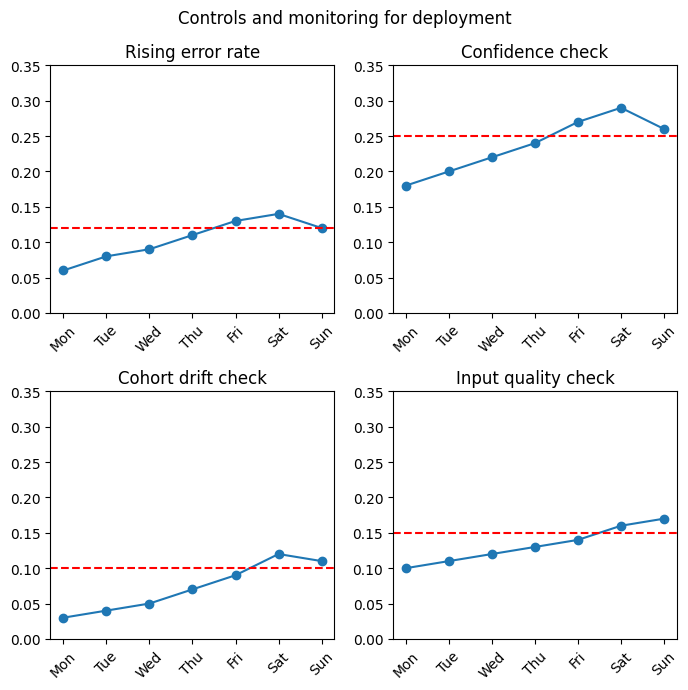

In [5]:
#@title Python Code - Controls and Monitoring

# This script teaches simple AI risk controls.
# It uses a civil engineering example.
# Monitoring links risks to practical checks.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seeds for repeatable classroom results.
np.random.seed(7)

# Define a small deployed AI example.
system_name = "Bridge crack triage AI"
asset_types = ["bridge", "bridge", "tunnel", "bridge"]

# Build a simple risk register table.
risk_register = pd.DataFrame({
    "Risk": [

        "Rising false negatives",
        "Low confidence predictions",
        "Cohort drift in asset type",

        "Poor image quality inputs"],
    "Control": [
        "Engineer reviews severe no-crack cases",

        "Send low-confidence cases to manual review",
        "Use only approved bridge image cohorts",
        "Reject blurry or dark images"],

    "Monitoring metric": [
        "Miss rate",
        "Low-confidence rate",

        "Tunnel image share",
        "Poor-quality image rate"],
    "Alert threshold": [

        "> 0.12",
        "> 0.25",
        "> 0.10",

        "> 0.15"],
    "Review frequency": [
        "Weekly",

        "Daily",
        "Weekly",
        "Daily"]})

# Create tiny monitoring data for one week.
monitoring = pd.DataFrame({
    "day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],

    "miss_rate": [0.06, 0.08, 0.09, 0.11, 0.13, 0.14, 0.12],
    "low_conf_rate": [0.18, 0.20, 0.22, 0.24, 0.27, 0.29, 0.26],
    "tunnel_share": [0.03, 0.04, 0.05, 0.07, 0.09, 0.12, 0.11],

    "poor_quality_rate": [0.10, 0.11, 0.12, 0.13, 0.14, 0.16, 0.17]})

# Check the table sizes before plotting.
if monitoring.shape[0] != 7:
    raise ValueError("Expected seven daily records.")

# Store thresholds in a simple dictionary.
thresholds = {
    "miss_rate": 0.12,

    "low_conf_rate": 0.25,
    "tunnel_share": 0.10,
    "poor_quality_rate": 0.15}

# Calculate latest values and alert flags.
latest = monitoring.iloc[-1]
summary = pd.DataFrame({

    "Metric": [
        "Miss rate",
        "Low-confidence rate",

        "Tunnel image share",
        "Poor-quality image rate"],
    "Latest": [

        latest["miss_rate"],
        latest["low_conf_rate"],
        latest["tunnel_share"],

        latest["poor_quality_rate"]],
    "Threshold": [0.12, 0.25, 0.10, 0.15]})

# Mark whether each metric needs attention.
summary["Alert"] = summary["Latest"] > summary["Threshold"]

# Print a short teaching summary.
print("AI system:", system_name)
print("Updated risk register:")

print(risk_register.to_string(index=False))
print("\nLatest monitoring check:")
print(summary.to_string(index=False))

# Create a compact monitoring summary figure.
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes = axes.ravel()

# Plot each metric against its threshold.
metric_names = [
    "miss_rate",

    "low_conf_rate",
    "tunnel_share",
    "poor_quality_rate"]

plot_titles = [
    "Rising error rate",
    "Confidence check",

    "Cohort drift check",
    "Input quality check"]

# Draw simple lines for beginners.
for i in range(4):
    name = metric_names[i]

    axes[i].plot(monitoring["day"], monitoring[name], marker="o")
    axes[i].axhline(thresholds[name], color="red", linestyle="--")
    axes[i].set_title(plot_titles[i])

    axes[i].set_ylim(0, 0.35)
    axes[i].tick_params(axis="x", rotation=45)

# Add one shared figure title.
fig.suptitle("Controls and monitoring for deployment")
plt.tight_layout()

plt.show()

### **2.3. Escalation and rollback**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_02_03.jpg?v=1777047384" width="250">



>* Escalation plans assign actions and authority.
>* Risk registers need clear warning triggers.

>* Rollback restores safer operations when AI fails.
>* Risk registers must detail practical rollback steps.

>* Communicate issues clearly using documented escalation pathways.
>* After rollback, investigate causes before restoring service.



Model: Bridge inspection priority model
Latest week: W4
Decision: Suspend automated outputs
Escalation: Alert supervisor immediately
Rollback: Revert to manual review
Follow up: Investigate and retrain before restart
Flow table:
                 condition                  response
FNR < 0.15 and data stable       Continue automation
        0.15 <= FNR < 0.22          Alert supervisor
               FNR >= 0.22 Suspend and manual review
      Missing data >= 0.08        Pause and fix data


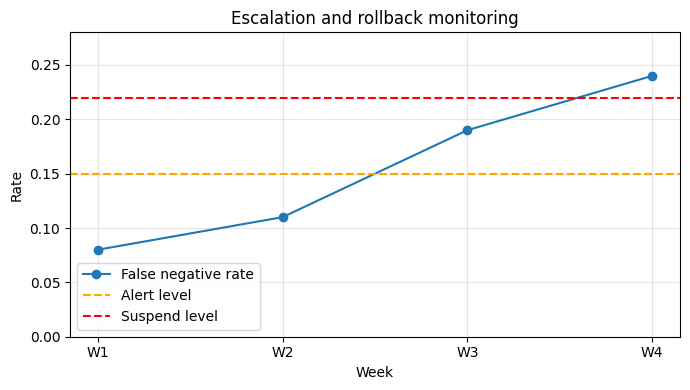

In [6]:
#@title Python Code - Escalation and rollback

# This script teaches escalation and rollback.
# It uses a simple bridge model.
# The example stays small and practical.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seeds for repeatable classroom results.
np.random.seed(7)

# Define a small model deployment context.
model_name = "Bridge inspection priority model"
current_version = "v2"

rollback_version = "v1"

# Create simple weekly monitoring data.
weeks = ["W1", "W2", "W3", "W4"]
false_negative_rate = [0.08, 0.11, 0.19, 0.24]

missing_input_rate = [0.01, 0.03, 0.05, 0.09]
complaints = [0, 1, 2, 4]

# Build a compact monitoring table.
monitor_df = pd.DataFrame({
    "week": weeks,

    "false_negative_rate": false_negative_rate,
    "missing_input_rate": missing_input_rate,
    "user_complaints": complaints})

# Set beginner friendly governance thresholds.
alert_threshold = 0.15
suspend_threshold = 0.22

missing_data_threshold = 0.08
complaint_threshold = 3

# Read the latest monitoring values.
latest = monitor_df.iloc[-1]
latest_fnr = latest["false_negative_rate"]

latest_missing = latest["missing_input_rate"]
latest_complaints = latest["user_complaints"]

# Start with a normal operating decision.
action = "Continue automated outputs"
escalation = "No escalation needed"

rollback = "Keep current model"
follow_up = "Routine weekly monitoring"

# Apply simple escalation and rollback rules.
if latest_fnr >= suspend_threshold:
    action = "Suspend automated outputs"

    escalation = "Alert supervisor immediately"
    rollback = "Revert to manual review"
    follow_up = "Investigate and retrain before restart"

elif latest_missing >= missing_data_threshold:
    action = "Pause model use"
    escalation = "Alert data engineer and supervisor"

    rollback = "Use previous validated process"
    follow_up = "Fix data feed and retest"
elif latest_complaints >= complaint_threshold:

    action = "Escalate for human review"
    escalation = "Alert supervisor today"
    rollback = "Check recent decisions manually"

    follow_up = "Review complaints and retrain if needed"
elif latest_fnr >= alert_threshold:
    action = "Keep model with extra checks"

    escalation = "Alert supervisor"
    rollback = "Prepare rollback to " + rollback_version
    follow_up = "Plan retraining and daily monitoring"

# Create a simple risk register.
risk_register = pd.DataFrame({
    "risk": [

        "Missed high risk bridge defects",
        "Missing sensor or inspection inputs",
        "User trust drops after complaints"],

    "trigger": [
        "False negative rate above 0.15",
        "Missing input rate above 0.08",

        "Three or more complaints"],
    "control": [
        "Supervisor review and threshold checks",

        "Input validation before scoring",
        "Complaint logging and weekly review"],
    "monitoring": [

        "Check weekly error trend",
        "Check missing data each batch",
        "Count complaints each week"]})

# Create a compact decision flow table.
flow_df = pd.DataFrame({
    "condition": [

        "FNR < 0.15 and data stable",
        "0.15 <= FNR < 0.22",
        "FNR >= 0.22",

        "Missing data >= 0.08"],
    "response": [
        "Continue automation",

        "Alert supervisor",
        "Suspend and manual review",
        "Pause and fix data"]})

# Print a short teaching summary.
print("Model:", model_name)
print("Latest week:", latest["week"])

print("Decision:", action)
print("Escalation:", escalation)
print("Rollback:", rollback)

print("Follow up:", follow_up)
print("Flow table:")
print(flow_df.to_string(index=False))

# Draw one compact governance chart.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weeks, false_negative_rate, marker="o", label="False negative rate")

ax.axhline(alert_threshold, color="orange", linestyle="--", label="Alert level")
ax.axhline(suspend_threshold, color="red", linestyle="--", label="Suspend level")
ax.set_title("Escalation and rollback monitoring")

ax.set_xlabel("Week")
ax.set_ylabel("Rate")
ax.set_ylim(0, 0.28)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## **3. Governance Readiness Checks**

### **3.1. Readiness Review Questions**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_03_01.jpg?v=1777047422" width="250">



>* Check purpose, decisions, and error consequences.
>* Confirm clear boundaries and real engineering need.

>* Check data, performance, and stated limitations.
>* Document edge cases and real-world weaknesses.

>* Plan ownership, monitoring, incidents, and intervention.
>* Readiness needs ongoing oversight and withdrawal routes.



Use case: Bridge crack detection assistant

Checklist table:
                  Category  Status  Score
              Intended use     Yes      2
              Data quality Partial      1
        Cohort performance Partial      1
           Human oversight     Yes      2
       Fallback procedures Partial      1
Documentation completeness     Yes      2

Readiness score: 9 out of 12
Readiness percent: 75.0%
Decision: Conditionally ready


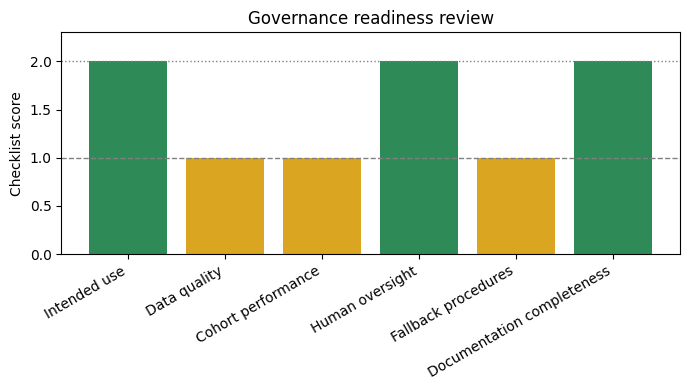

In [7]:
#@title Python Code - Readiness Review Questions

# This script checks AI governance readiness.
# It uses a simple civil example.
# Results include a score and plot.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a seed for consistency.
np.random.seed(7)

# Define one bridge inspection use case.
use_case_name = "Bridge crack detection assistant"
checklist = pd.DataFrame({

    "Category": [
        "Intended use", "Data quality", "Cohort performance",
        "Human oversight", "Fallback procedures", "Documentation completeness"],

    "Question": [
        "Is the engineering purpose clearly defined?",
        "Are data sources recent and representative?",

        "Is performance checked across bridge groups?",
        "Does a human make final decisions?",
        "Is there a safe backup process?",

        "Are model card and risk notes complete?"],
    "Score": [2, 1, 1, 2, 1, 2]})

# Add simple status labels.
status = []
for value in checklist["Score"]:

    if value == 2:
        status.append("Yes")
    elif value == 1:

        status.append("Partial")
    else:
        status.append("No")

checklist["Status"] = status

# Calculate readiness summary values.
max_score = int(len(checklist) * 2)
total_score = int(checklist["Score"].sum())

percent_score = round(100 * total_score / max_score, 1)

# Decide the readiness level.
if percent_score >= 80:
    readiness = "Ready"

elif percent_score >= 50:
    readiness = "Conditionally ready"
else:

    readiness = "Not ready"

# Show a compact checklist table.
print("Use case:", use_case_name)
print("\nChecklist table:")

print(checklist[["Category", "Status", "Score"]].to_string(index=False))
print("\nReadiness score:", total_score, "out of", max_score)
print("Readiness percent:", str(percent_score) + "%")

print("Decision:", readiness)

# Create a compact bar chart.
colors = []
for value in checklist["Score"]:

    if value == 2:
        colors.append("seagreen")
    elif value == 1:

        colors.append("goldenrod")
    else:
        colors.append("firebrick")

# Plot category scores and threshold lines.
plt.figure(figsize=(7, 4))
plt.bar(checklist["Category"], checklist["Score"], color=colors)

plt.axhline(1, color="gray", linestyle="--", linewidth=1)
plt.axhline(2, color="gray", linestyle=":", linewidth=1)
plt.ylim(0, 2.3)

plt.ylabel("Checklist score")
plt.title("Governance readiness review")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### **3.2. Approval Sign Offs**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_03_02.jpg?v=1777047451" width="250">



>* Sign off needs cross-functional stakeholder review.
>* Checks purpose, risks, documentation, and oversight.

>* Sign offs assign accountability and approval limits.
>* Multiple reviewers ensure safeguards and local validation.

>* Approvals are conditional, limited, and revisable.
>* Reapproval follows changes, expansion, or errors.



Stakeholder sign off table
           Role                   Status       Date                               Conditions                              Comments
       Engineer                 Approved 2026-04-24         Use only for inspection support.   Model card reviewed and acceptable.
      Inspector Approved with Conditions 2026-04-24 Human review required before scheduling.    Local image quality checks needed.
Project Manager                  Pending Not signed         Await pilot budget confirmation. Operational rollout not yet approved.
Safety Reviewer                 Approved 2026-04-24    Escalate high risk cases immediately.     Safety limits clearly documented.

Ready to proceed: False


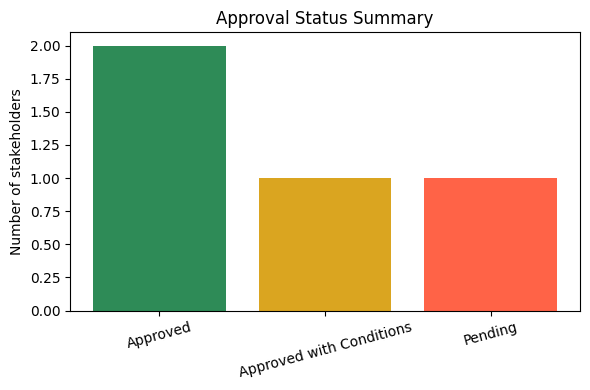

In [8]:
#@title Python Code - Approval Sign Offs

# This script demonstrates simple approval sign offs.
# It uses pandas for governance tracking.
# The example fits civil engineering AI review.

import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

# Create a small sign off dataset.
today_text = str(date.today())
sign_offs = pd.DataFrame({

        "Role": [
            "Engineer",
            "Inspector",

            "Project Manager",
            "Safety Reviewer",],

        "Status": [
            "Approved",
            "Approved with Conditions",

            "Pending",
            "Approved",],

        "Date": [
            today_text,
            today_text,

            "Not signed",
            today_text,],

        "Conditions": [
            "Use only for inspection support.",
            "Human review required before scheduling.",

            "Await pilot budget confirmation.",
            "Escalate high risk cases immediately.",],

        "Comments": [
            "Model card reviewed and acceptable.",
            "Local image quality checks needed.",

            "Operational rollout not yet approved.",
            "Safety limits clearly documented.",],})

# Show a readable compact table.
print("Stakeholder sign off table")
print(sign_offs.to_string(index=False))

# Count each approval status.
status_counts = sign_offs["Status"].value_counts()
status_order = [

    "Approved",
    "Approved with Conditions",
    "Pending",]

# Reindex for a stable chart order.
status_counts = status_counts.reindex(
    status_order,

    fill_value=0,)

# Check whether governance is ready.
all_signed = "Pending" not in list(sign_offs["Status"])
print("\nReady to proceed:", all_signed)

# Draw a compact status summary chart.
plt.figure(figsize=(6, 4))
plt.bar(

    status_counts.index,
    status_counts.values,
    color=["seagreen", "goldenrod", "tomato"],)

# Add chart labels clearly.
plt.title("Approval Status Summary")
plt.ylabel("Number of stakeholders")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### **3.3. Document Update Cycle**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_13/Lecture_B/image_03_03.jpg?v=1777047478" width="250">



>* Documents need regular updates as systems change.
>* Track reviews, changes, approvals, and impacts.

>* Use scheduled and event-driven document reviews.
>* Record changes, impacts, and needed approvals.

>* Assign ownership and track document versions.
>* Record impacts, approvals, and communicate updates.



Model card versions:
                                                                 v1                                                              v2
version                                                          v1                                                              v2
model_name                         Bridge Inspection Priority Model                                Bridge Inspection Priority Model
purpose         Prioritize bridge inspections after routine reviews  Prioritize bridge inspections after storms and routine reviews
data_source                2019-2023 inspection and weather records                2019-2024 inspection, weather, and drone records
performance_f1                                                 0.78                                                            0.83
limitations                     Weaker performance on rural bridges                           Night drone images remain challenging
last_review                                            

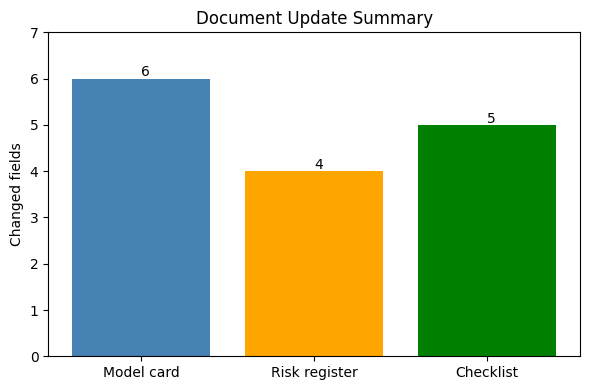

In [9]:
#@title Python Code - Document Update Cycle

# This script shows governance document updates.
# It compares versions after model changes.
# Civil engineering examples keep ideas practical.

import json
import pandas as pd
import matplotlib.pyplot as plt

# Build version one governance records.
model_card_v1 = {
    "version": "v1",

    "model_name": "Bridge Inspection Priority Model",
    "purpose": "Prioritize bridge inspections after routine reviews",
    "data_source": "2019-2023 inspection and weather records",

    "performance_f1": 0.78,
    "limitations": "Weaker performance on rural bridges",
    "last_review": "2025-01-15"}

risk_register_v1 = {
    "version": "v1",
    "top_risk": "Missed deterioration in rural areas",

    "control": "Engineer review before scheduling",
    "monitoring": "Quarterly error audit",
    "owner": "Asset management team"}

governance_v1 = {
    "version": "v1",
    "approval_status": "Approved with monitoring",

    "review_trigger": "Quarterly review",
    "next_review": "2025-04-15",
    "deployment_scope": "State highway bridges only"}

# Build version two after retraining.
model_card_v2 = {
    "version": "v2",

    "model_name": "Bridge Inspection Priority Model",
    "purpose": "Prioritize bridge inspections after storms and routine reviews",
    "data_source": "2019-2024 inspection, weather, and drone records",

    "performance_f1": 0.83,
    "limitations": "Night drone images remain challenging",
    "last_review": "2025-04-20"}

risk_register_v2 = {
    "version": "v2",
    "top_risk": "Night images may hide small cracks",

    "control": "Engineer review plus camera quality check",
    "monitoring": "Monthly drift and complaint review",
    "owner": "Asset management team"}

governance_v2 = {
    "version": "v2",
    "approval_status": "Conditional approval after update",

    "review_trigger": "Quarterly and event-driven review",
    "next_review": "2025-07-20",
    "deployment_scope": "State highways and selected rural bridges"}

# Convert records into side-by-side tables.
model_df = pd.DataFrame({"v1": model_card_v1, "v2": model_card_v2})
risk_df = pd.DataFrame({"v1": risk_register_v1, "v2": risk_register_v2})

gov_df = pd.DataFrame({"v1": governance_v1, "v2": governance_v2})

# Find changed fields in one table.
def changed_rows(table_df):
    changed = table_df[table_df["v1"] != table_df["v2"]].copy()

    changed = changed.reset_index()
    changed.columns = ["field", "v1", "v2"]
    return changed

# Create compact change summaries.
model_changes = changed_rows(model_df)
risk_changes = changed_rows(risk_df)

gov_changes = changed_rows(gov_df)

# Count changes for the figure.
change_counts = [len(model_changes), len(risk_changes), len(gov_changes)]
labels = ["Model card", "Risk register", "Checklist"]

# Print short governance outputs.
print("Model card versions:")
print(model_df.head(7).to_string())

print("\nRisk register versions:")
print(risk_df.head(4).to_string())
print("\nChecklist versions:")

print(gov_df.head(4).to_string())

# Build a short change log.
change_log = [
    "Retraining added drone records.",

    "Performance improved from 0.78 to 0.83.",
    "Monitoring became monthly and event-driven.",
    "Approval changed to conditional after update."]

# Print a compact change log.
print("\nChange log:")
print("; ".join(change_log))

# Judge readiness using simple checks.
ready = True
if model_card_v2["performance_f1"] < model_card_v1["performance_f1"]:

    ready = False
if "Conditional" in governance_v2["approval_status"]:
    ready = False

if "Monthly" not in risk_register_v2["monitoring"]:
    ready = False

# Print the governance decision.
if ready:
    print("Decision: Ready to proceed responsibly.")

else:
    print("Decision: Update noted, extra review still needed.")

# Save one small JSON snapshot.
snapshot = {
    "model_card_v2": model_card_v2,

    "risk_register_v2": risk_register_v2,
    "governance_v2": governance_v2}

# Show JSON text briefly.
json_text = json.dumps(snapshot, indent=2)
print("JSON snapshot saved in memory.")

# Draw a compact update summary figure.
plt.figure(figsize=(6, 4))
plt.bar(labels, change_counts, color=["steelblue", "orange", "green"])

plt.title("Document Update Summary")
plt.ylabel("Changed fields")
plt.ylim(0, max(change_counts) + 1)

# Add values above bars.
for i in range(len(labels)):
    plt.text(i, change_counts[i] + 0.05, str(change_counts[i]))

plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Model Cards and Governance**</font>


In this lecture, you learned to:
- Create a concise model card that documents a civil engineering AI model’s purpose, data, performance, and limitations. 
- Draft a simple risk register that records key risks, controls, and monitoring plans for an AI deployment. 
- Evaluate whether a proposed AI use case has sufficient documentation and governance to proceed responsibly. 

In spring & fall semesters, the next Module, Module 14, will be the Final week with no lectures. In the summer semesters, Module 13 will be the last Module of the course. For the summer Final Project, please follow the course announcements and the course outline. 